In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 300
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\UseR\Documents\Data science Assignment\Logistic Regression\Logistic Regression\Titanic_train.csv", sep=',', skipinitialspace=True)

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.shape

(891, 12)

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Check for Missing Values

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
##Calculate the percentage of missing values in each column.
for i in df.isnull().sum():
    print(i/len(df)*100)

0.0
0.0
0.0
0.0
0.0
19.865319865319865
0.0
0.0
0.0
0.0
77.10437710437711
0.22446689113355783


# Handling Missing Values

# * Age: Fill with median

In [8]:
df['Age'].median()

28.0

In [9]:
Age_Median = df['Age'].median()

In [10]:
df['Age'].fillna(Age_Median, inplace = True)

# * Embarked: Fill with mode (most common port)

In [11]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [12]:
df['Embarked'].mode()[0]

'S'

In [13]:
Embarked_mode = df['Embarked'].mode()[0]

In [14]:
df['Embarked'].fillna(Embarked_mode, inplace = True)

# * Cabin: Too many missing values, drop

In [15]:
df.drop(columns=['Cabin'], inplace=True)

In [16]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Drop Unnecessary Columns

In [17]:
# These aren’t useful for modeling:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [18]:
df.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [19]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [20]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [21]:
df.duplicated().sum()

116

In [22]:
df.drop_duplicates(inplace = True)

In [ ]:
# 4. Convert categorical columns to numeric
df = pd.get_dummies(df, drop_first=True)  # handles Sex, Embarked

In [47]:
df = df.astype(int)


In [48]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22,1,0,7,1,0,1
1,1,1,38,1,0,71,0,0,0
2,1,3,26,0,0,7,0,0,1
3,1,1,35,1,0,53,0,0,1
4,0,3,35,0,0,8,1,0,1
...,...,...,...,...,...,...,...,...,...
885,0,3,39,0,5,29,0,1,0
887,1,1,19,0,0,30,0,0,1
888,0,3,28,1,2,23,0,0,1
889,1,1,26,0,0,30,1,0,0


# Model Building

# Step 1: Define x and y

In [49]:
df.head(2)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22,1,0,7,1,0,1
1,1,1,38,1,0,71,0,0,0


In [50]:
# Target
y = df['Survived']

# Features
x = df.drop(columns = ['Survived'])


In [51]:
y

0      0
1      1
2      1
3      1
4      0
      ..
885    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 775, dtype: int32

In [52]:
x

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22,1,0,7,1,0,1
1,1,38,1,0,71,0,0,0
2,3,26,0,0,7,0,0,1
3,1,35,1,0,53,0,0,1
4,3,35,0,0,8,1,0,1
...,...,...,...,...,...,...,...,...
885,3,39,0,5,29,0,1,0
887,1,19,0,0,30,0,0,1
888,3,28,1,2,23,0,0,1
889,1,26,0,0,30,1,0,0


# Step 2: Split data into trainig and testing

In [53]:
from sklearn.model_selection import train_test_split

In [57]:
train_test_split(x,y,train_size=0.8)

[     Pclass  Age  SibSp  Parch  Fare  Sex_male  Embarked_Q  Embarked_S
 529       2   23      2      1    11         1           0           1
 255       3   29      0      2    15         0           0           0
 109       3   28      1      0    24         0           1           0
 160       3   44      0      1    16         1           0           1
 27        1   19      3      2   263         1           0           1
 ..      ...  ...    ...    ...   ...       ...         ...         ...
 645       1   48      1      0    76         1           0           0
 277       2   28      0      0     0         1           0           1
 609       1   40      0      0   153         0           0           1
 199       2   24      0      0    13         0           0           1
 658       2   23      0      0    13         1           0           1
 
 [620 rows x 8 columns],
      Pclass  Age  SibSp  Parch  Fare  Sex_male  Embarked_Q  Embarked_S
 290       1   26      0      0    78

In [58]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2, random_state = 42)

In [59]:
xtrain

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
143,3,19,0,0,6,1,1,0
862,1,48,0,0,25,0,0,1
57,3,28,0,0,7,1,0,0
448,3,5,2,1,19,0,0,0
768,3,28,1,0,24,1,1,0
...,...,...,...,...,...,...,...,...
73,3,26,1,0,14,1,0,0
114,3,17,0,0,14,0,0,0
289,3,22,0,0,7,0,1,0
486,1,35,1,0,90,0,0,1


In [60]:
ytrain

143    0
862    1
57     0
448    1
768    0
      ..
73     0
114    0
289    1
486    1
110    0
Name: Survived, Length: 620, dtype: int32

# Step 3: Model building

In [61]:
from sklearn.linear_model import LogisticRegression

In [62]:
lg = LogisticRegression() #variable/object
lg.fit(xtrain,ytrain) #Training /calculation

LogisticRegression()

In [63]:
xtest

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
477,3,29,1,0,7,1,0,1
813,3,6,4,2,31,0,0,1
353,3,25,1,0,17,1,0,1
879,1,56,0,1,83,0,0,0
396,3,31,0,0,7,0,0,1
...,...,...,...,...,...,...,...,...
158,3,28,0,0,8,1,0,1
360,3,40,1,4,27,1,0,1
523,1,44,0,1,57,0,0,0
314,2,43,1,1,26,1,0,1


In [64]:
ytest

477    0
813    0
353    0
879    1
396    0
      ..
158    0
360    0
523    1
314    0
652    0
Name: Survived, Length: 155, dtype: int32

In [66]:
xtest.shape

(155, 8)

In [67]:
xtest

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
477,3,29,1,0,7,1,0,1
813,3,6,4,2,31,0,0,1
353,3,25,1,0,17,1,0,1
879,1,56,0,1,83,0,0,0
396,3,31,0,0,7,0,0,1
...,...,...,...,...,...,...,...,...
158,3,28,0,0,8,1,0,1
360,3,40,1,4,27,1,0,1
523,1,44,0,1,57,0,0,0
314,2,43,1,1,26,1,0,1


# Step 4: Make Predictions

In [69]:
ypred = lg.predict(xtest)

In [70]:
ypred 

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0])

In [81]:
print(ytest[:25].values) #actual
print(ypred[:25]) #predicted

[0 0 0 1 0 1 0 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 1 1]
[0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 1 1]


# Step 5: Evaluation

In [84]:
from sklearn.metrics import confusion_matrix, classification_report

In [90]:
cm = confusion_matrix(ytest, ypred)  # sequence -> tn, fp, fn, tp

In [92]:
cm 

array([[77, 18],
       [18, 42]], dtype=int64)

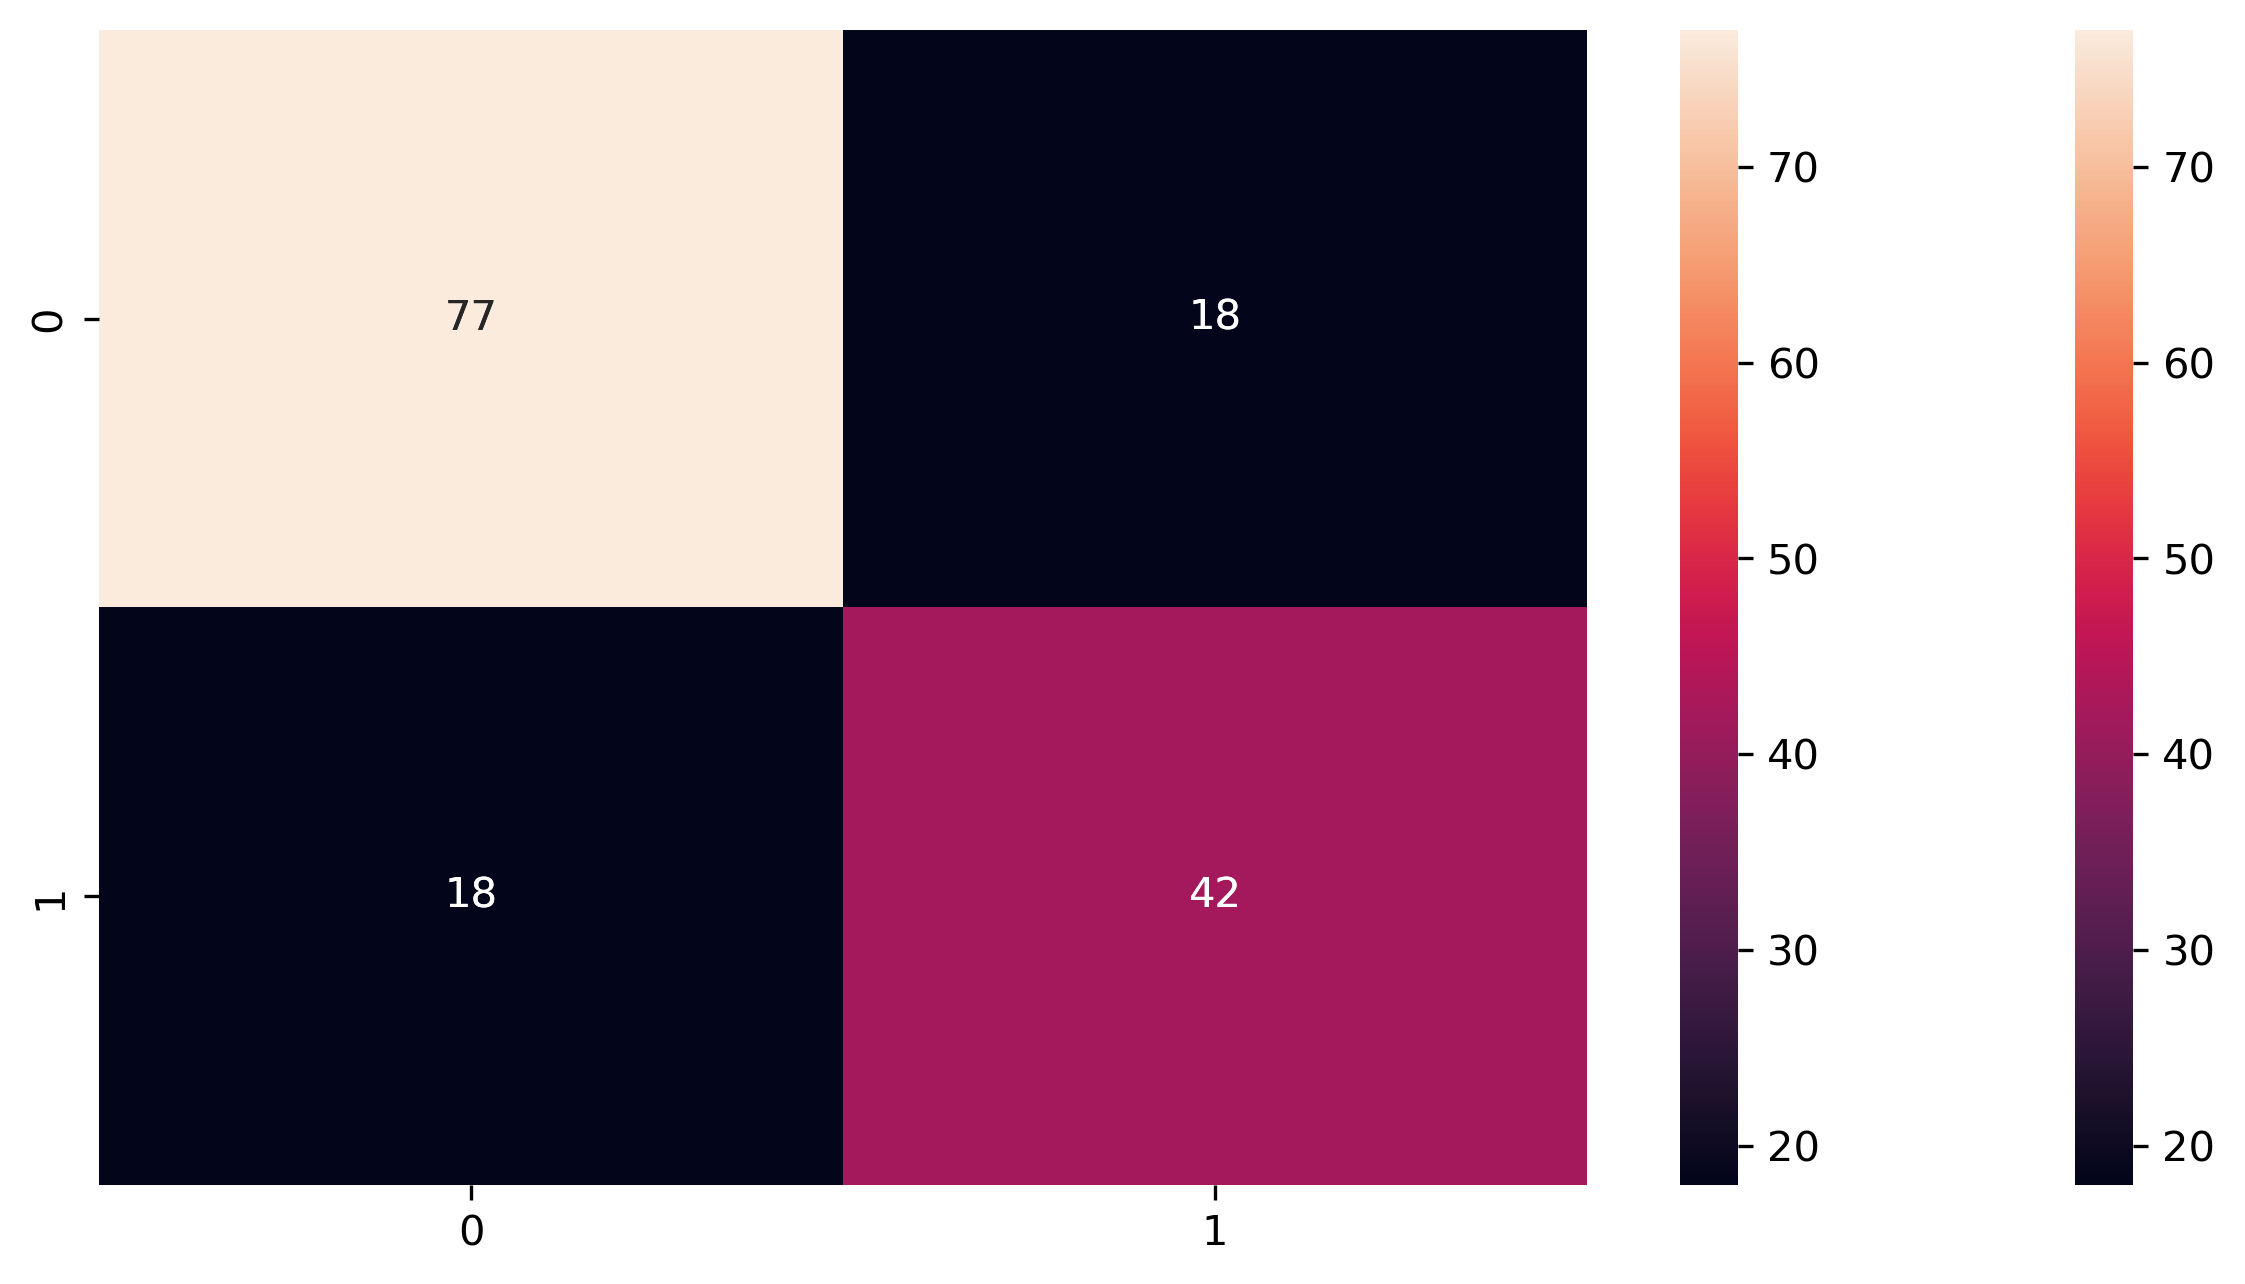

In [94]:
sns.heatmap(cm , annot=True)
plt.show()

In [96]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81        95
           1       0.70      0.70      0.70        60

    accuracy                           0.77       155
   macro avg       0.76      0.76      0.76       155
weighted avg       0.77      0.77      0.77       155

